## Przygotowanie

Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko.
{nr_albumu}\_{imię}\_{nazwisko}\_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez TEAMS.

## Regresja wielomianowa

Regresja liniowa działa dobrze w sytuacji, gdy zmienna, której wartość chemy przewidzieć (zmienna objaśniana/zależna) jest liniowo zależna od zmiennych za pomocą których chcemy ją obliczyć (zmiennych objaśniających/niezależnych). Jak nietrudno się domyślić, takie założenie jest mocno ograniczające i w realnych problemach rzadko będzie ono spełniane. Pojawia się zatem pytanie, co zrobić, gdy wiemy, że dane nie spełniają założenia o liniowej zależności. Istnieje wiele algorytmów rozwiązujących takie problemy. Jednym z nich jest regresja wielomianowa.

Regresja wielomianowa polega na zmianie funkcji regresji tak, aby była to funkcja wielomianowa. Przykładowo, dla jednej zmiennej niezależnej można stworzyć model, którego funkcja regresji będzie wielomianem czwartego stopnia: 

\begin{equation}
f(x) = \beta_{0} + \beta_{1}x_1 + \beta_{2}x_1^2 + \beta_{3}x_1^3 + \beta_{4}x_1^4
\end{equation}

Pozwala to na stworzenie dowolnego kształtu funkcji, który będzie dopasowany do danych. Zwiekszanie krotności wielomianu spowoduje dokładniejsze dopasowanie do danych, jednak rodzi też pewne niebezpieczeństwa. Może okazać się, że taki model będzie zbyt mocno dopasowany do próbek uczących i nie będzie w stanie dokonywać poprawnych predykcji dla nowych, nieznanych próbek. Takie zjawisko nazywa się przeuczeniem modelu i istnieją różne metody do jego rozpoznania i przeciwdziałania. Nie jest to jednak przedmiotem tego notatnika. 

Cały proces trenowania i testowania modelu wygląda jak w przypadku regresji liniowej. Różnica polega jedynie na zmianie funkcji regresji.

Zbiór danych do tego zadania znajduje się w pliku "jaws.csv" i przedstawia zależność długości kości szczękowej jelenia od jego wieku. 

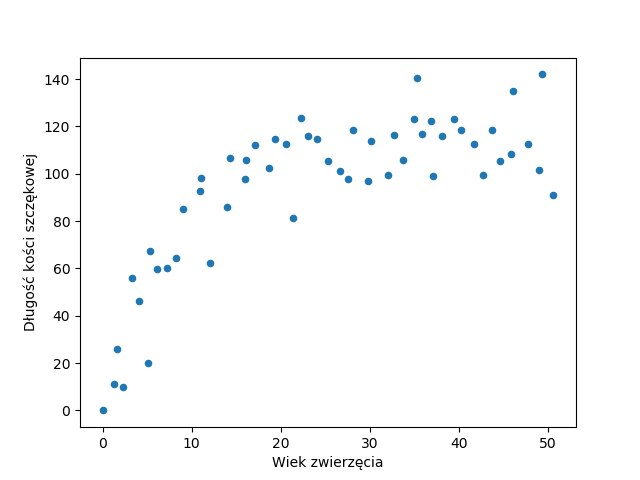

Na powyższym wykresie widać, że zależność na pewno nie jest liniowa. Szczęka zwierzęcia rośnie do pewnego wieku i później jej długość jest stała przez resztę życia. Spróbujemy rozwiązać ten problem za pomocą regresji wielomianowej.


In [1]:
import pandas as pd
from typing import Tuple, Optional, Union
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import time
import numpy as np

In [2]:
df = pd.read_csv('jaws.csv')

### Zadanie 1
Aby stworzyć funkcję wielomianową konieczne jest dodanie nowych cech do istniejącego zestawu danych.
Stwórz funkcję, która przetransformuje pojedynczą cechę do wektora cech, w którym kolejne elementy, to kolejne potęgi danej cechy.

Przykład:
transform_to_polynomial_feature(x, 5) -> $[x^1, x^2, x^3, x^4, x^5]$
transform_to_polynomial_feature(x, 3) -> $[x^1, x^2, x^3]$

In [3]:


'''
input:
x - wartość zmiennej niezależnej
n - stopień wielomianu

output:
out: [] - lista o długości n z kolejnymi potęgami wejściowej cechy x
'''


def transform_to_polynomial_feature(x: np.ndarray, n: int) -> np.ndarray:
    out = []
    for i in range(n):
        out.append(x ** (i + 1))
    return np.array(out)

In [4]:
x = df['age'].values
y = df['bone'].values

### Zadanie 2

Zmodyfikuj swój kod z zadania z regresją liniową tak, aby dla zestawu danych x z jedną zmienną niezależną tworzył nieliniową funkcję regresji. Przetestuj rozwiązanie dla różnych wariantów stopnia wielomianu.
Pamiętaj, że konieczne dodanie dodatkowych cech do oryginalnego zbioru danych, które będą kolejnymi potęgami zmiennej niezależnej - wiek zwierzęcia.

**UWAGA:** Przed podaniem zestaw
u danych na wejście modelu pomocna może okazać się operacja normalizacji danych, której celem jest sprowadzenie wartości cech do wspólnych przedziałów wartości. Aby to osiągnąc można wykorzystać [gotowe rozwiązania do standaryzacji lub skalowania min-max](https://scikit-learn.org/stable/modules/preprocessing.html) albo zaimplementować skalowanie samemu korzystając ze [wzoru](https://pl.wikipedia.org/wiki/Standaryzacja_(statystyka)).

In [5]:
def initialize_coefficients(n: int = 2, alpha: float = 0.01) -> Tuple[float, np.ndarray]:
    eps = np.finfo(float).eps
    betas = np.random.uniform(eps, 1 - eps, size=n)
    return alpha, betas


def calculate_regression_function(X: np.ndarray, betas: np.ndarray) -> np.ndarray:
    return betas[0] + X.dot(betas[1:])


def calculate_error(predictions: np.ndarray, y: np.ndarray) -> float:
    m = len(predictions)
    return (1.0 / (2 * m)) * np.sum((predictions - y) ** 2)


def calculate_gradient(X: np.ndarray, predictions: np.ndarray, y: np.ndarray) -> np.ndarray:
    m = len(predictions)
    error = predictions - y

    grad_0 = np.sum(error) / m
    grad_rest = (X.T.dot(error)) / m
    return np.hstack([grad_0, grad_rest])


def update_regression_coefficients(X: np.ndarray, predictions: np.ndarray, y: np.ndarray, betas: np.ndarray,
                                   alpha: float) -> np.ndarray:
    d_betas = calculate_gradient(X, predictions, y)
    betas_new = betas - alpha * d_betas
    return betas_new




In [6]:
def learn_and_fit(x: np.ndarray, y: np.ndarray, alpha: float = 0.01, n: int = 2,
                  normalization: Optional[str] = None,
                  max_epochs: int = 1000000,
                  tolerance: float = 1e-6,
                  patience: int = 100) -> Tuple[
    np.ndarray, np.ndarray, np.ndarray, Optional[Union[StandardScaler, MinMaxScaler]], int]:
    X = transform_to_polynomial_feature(x, n)
    X = X.T

    scaler = None
    if normalization == 'standard':
        scaler = StandardScaler()
        X_processed = scaler.fit_transform(X)
    else:
        X_processed = X

    b0_list = []
    betas_list = []
    errors_list = []
    alpha_coef, betas = initialize_coefficients(n + 1, alpha)

    best_error = float('inf')
    no_improvement_count = 0

    for ep in range(max_epochs):
        y_pred = calculate_regression_function(X_processed, betas)
        err = calculate_error(y_pred, y)
        betas = update_regression_coefficients(X_processed, y_pred, y, betas, alpha_coef)

        b0_list.append(betas[0])
        betas_list.append(betas[1:])
        errors_list.append(err)

        if best_error - err > tolerance:
            best_error = err
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        if no_improvement_count >= patience:
            print(f'Early stopping na epoce {ep + 1}. Brak poprawy przez {patience} epok.')
            break
    actual_epochs = len(errors_list)
    return np.array(b0_list), np.array(betas_list), np.array(errors_list), scaler, actual_epochs

Early stopping na epoce 31272. Brak poprawy przez 100 epok.


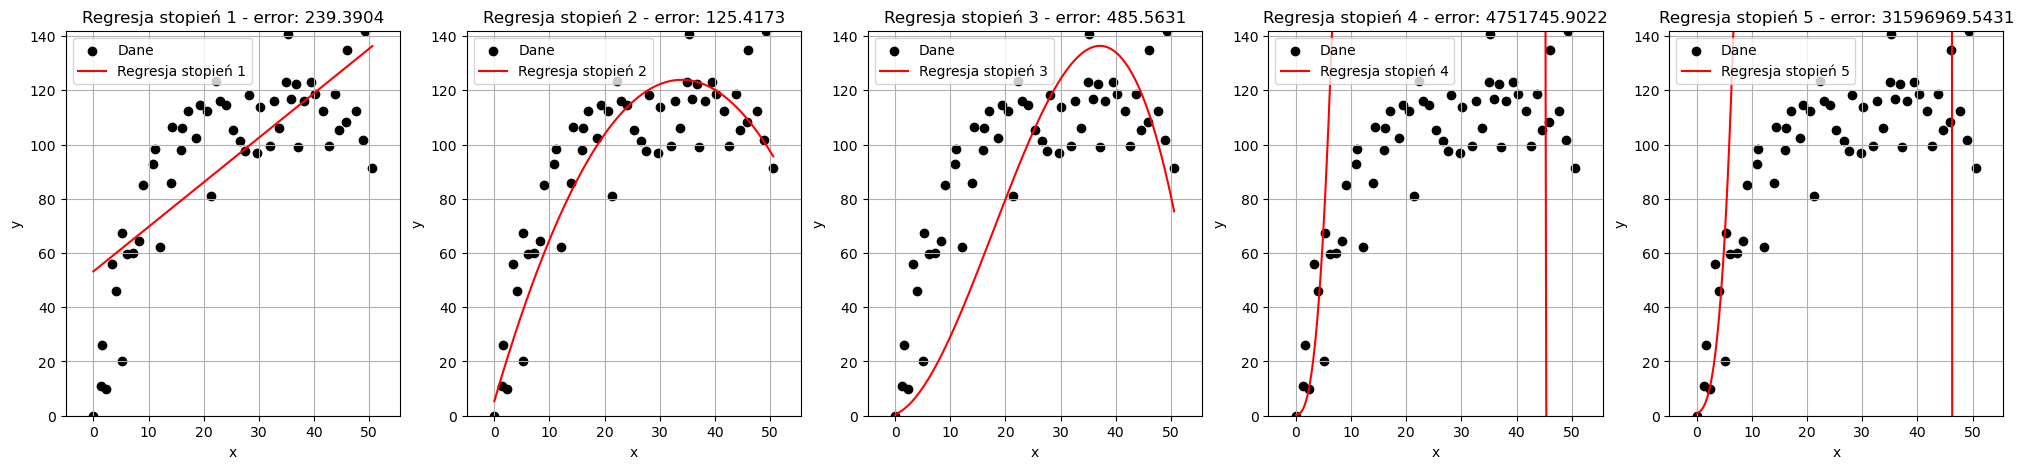

In [7]:
degrees = [1, 2, 3, 4, 5]
alphas = [0.001, 0.000001, 0.00000000001, 0.000000000000001, 0.00000000000000001]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

x_plot = np.linspace(x.min(), x.max(), 200)

for ax, n, alpha in zip(axes, degrees, alphas):
    b0_list, betas_list, errors_list, _, _ = learn_and_fit(x, y, alpha=alpha, n=n, max_epochs=2000000)
    b0 = b0_list[-1]
    betas = betas_list[-1]

    X_poly = np.vstack([x_plot ** i for i in range(1, len(betas) + 1)])
    y_fit = b0 + np.dot(betas, X_poly)
    ax.scatter(x, y, color='black', label='Dane')
    ax.plot(x_plot, y_fit, color='red', label=f'Regresja stopień {n}')
    ax.set_title(f'Regresja stopień {n} - error: {errors_list[-1]:.4f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(x.min() - 5, x.max() + 5)
    ax.set_ylim(y.min(), y.max())
    ax.legend(loc=2)
    ax.grid(True)



Widać że dla wyższych stopnii wielomianu model nie jest douczony

### Zadanie 3

Porównaj czasy działania algorytmu dla danych przed i po normalizacji

In [8]:
degrees = [1, 4, 5]
alphas = [0.001, 0.0000000000001, 0.0000000000000001]
alphas_stand = [0.1, 0.3, 0.2]
times_original = []
times_standard = []
epochs = 10

for i in range(len(alphas)):
    for j in range(epochs):
        print(f'Original: alpha={alphas[i]}, degree={degrees[i]}, epoch={j + 1}')
        start_time = time.time()
        results = learn_and_fit(x, y, alpha=alphas[i], n=degrees[i])
        time_delta = time.time() - start_time
        times_original.append(time_delta)

for i in range(len(alphas)):
    for j in range(epochs):
        print(f'Standard: alpha={alphas_stand[i]}, degree={degrees[i]}, epoch={j + 1}')
        start_time = time.time()
        results = learn_and_fit(x, y, alpha=alphas_stand[i], n=degrees[i], normalization='standard')
        time_delta = time.time() - start_time
        times_standard.append(time_delta)


Original: alpha=0.001, degree=1, epoch=1
Early stopping na epoce 31311. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=2
Early stopping na epoce 31276. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=3
Early stopping na epoce 31304. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=4
Early stopping na epoce 31279. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=5
Early stopping na epoce 31298. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=6
Early stopping na epoce 31300. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=7
Early stopping na epoce 31294. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=8
Early stopping na epoce 31250. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=9
Early stopping na epoce 31286. Brak poprawy przez 100 epok.
Original: alpha=0.001, degree=1, epoch=10
Early stopping na epoce 31306. Brak poprawy przez

In [9]:
summary = pd.DataFrame([times_original, times_standard],
                       index=['Original_time', 'Standard_time']).T

In [10]:
summary.describe()

,Original_time,Standard_time
count,30.000000,30.000000
mean,5.778657,3.764997
std,3.966375,3.320797
min,0.256914,0.001853
25%,0.269702,0.002886
50%,8.403530,3.325429
75%,8.541988,7.925137
max,8.927435,8.060587


Po przeprowadzeniu wstępnych testów zauważono że standaryzacja odgrywa kluczową rolę i pozwala na zmniejszenie parametru alpha. Przed standaryzacją konieczne było użycie bardzo małych wartości alpha. Inaczej widoczny był błąd 'RuntimeWarning: overflow encountered'. Po normalizacji można było użyć większych wartości alpha, co przyspieszyło proces uczenia. Widać to w wynikach gdzie średni czas działania dla oryginalnych danych jest znacznie większy niż dla danych po normalizacji.

### Zadanie 4

Stwórz wykres na którym będą znajdować się dane ze zbioru _jaws.csv_ oraz funkcje regresji wielomianowej dla wielomianu pierwszego, czwartego i piątego stopnia.

Opisz wykres. Jak zmienia się funkcja regresji wraz z dodawaniem kolejnych stopni wielomianu? Czy widzisz jakąś inną możliwą transformację funkcji regresji tak, żeby rozwiązała analizowany problem?

Early stopping na epoce 216. Brak poprawy przez 100 epok.
Early stopping na epoce 572186. Brak poprawy przez 100 epok.
Early stopping na epoce 943441. Brak poprawy przez 100 epok.


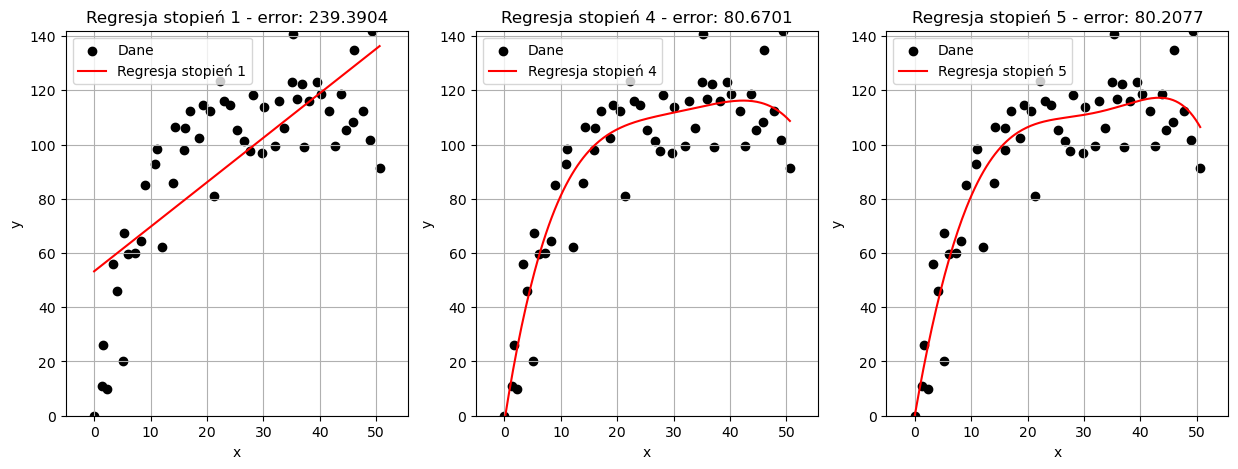

In [11]:
degrees = [1, 4, 5]
alphas = [0.1, 0.2, 0.2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x_plot = np.linspace(x.min(), x.max(), 200)

for ax, n, alpha in zip(axes, degrees, alphas):
    b0_list, betas_list, errors_list, scaler, _ = learn_and_fit(
        x, y, alpha=alpha, n=n, max_epochs=2000000, normalization='standard'
    )

    b0 = b0_list[-1]
    betas = betas_list[-1]

    X_poly = transform_to_polynomial_feature(x_plot, n).T

    X_poly_proc = scaler.transform(X_poly)

    y_fit = calculate_regression_function(X_poly_proc, np.concatenate([[b0], betas]))
    ax.scatter(x, y, color='black', label='Dane')
    ax.plot(x_plot, y_fit, color='red', label=f'Regresja stopień {n}')
    ax.set_title(f'Regresja stopień {n} - error: {errors_list[-1]:.4f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(x.min() - 5, x.max() + 5)
    ax.set_ylim(y.min(), y.max())
    ax.legend(loc=2)
    ax.grid(True)

plt.show()


Użycie wielomianu pierwszego stopnia daje nam prostą linię, która nie jest w stanie dobrze odwzorować zależności między wiekiem a długością kości szczękowej jelenia. Widać, że linia ta przecina dane w kilku miejscach, ale nie oddaje charakterystyki wzrostu kości. W przypadku wielomianu czwartego i piątego stopnia, funkcja zaczyna lepiej dopasowywać się do danych, pokazując krzywą, która rośnie szybko na początku, a następnie stabilizuje się. Wielomian piątego stopnia daje bardziej złożoną krzywą, która może lepiej dopasować się do danych, ale jednocześnie gdzie funkcja zaczyna nadmiernie reagować na szumy (mamy pare punków odległych od reszty od góry do których zaczyna się dostosowywać. Różnica w błedzie jest minimalna i wybór prostszego modelu  może być bardziej korzystny ze względu na mniejsze ryzyko przeuczenia.

Punkty układają się w kształt przypominający funkcję logarytmiczną, więc  alternatywną transformacją funkcji regresji mogłaby być ona.

 ### Zadanie 5

Odszukaj dowolny inny zbiór danych, dokonaj jego wizualizacji i przetestuj działania algorytmu

In [14]:
# Zbior danych znaleziony na Kaggle: Ice Cream Sales vs Temperature
ice_cream = pd.read_csv('Ice_cream selling data.csv')

In [15]:
ice_cream.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


Text(0, 0.5, 'Ice Cream Sales (units)')

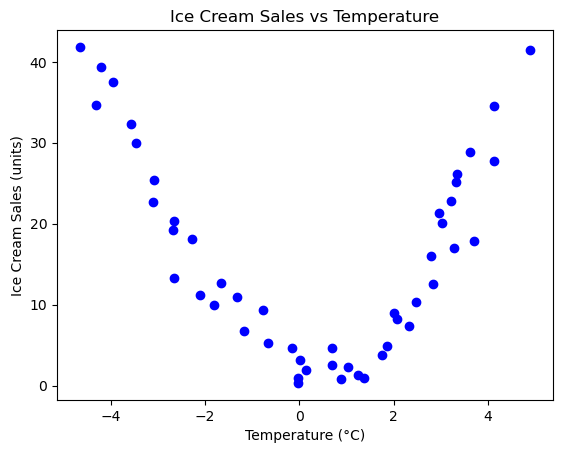

In [16]:
plt.scatter(ice_cream['Temperature (°C)'], ice_cream['Ice Cream Sales (units)'], color='blue')
plt.title('Ice Cream Sales vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')

In [17]:
x_ic = ice_cream['Temperature (°C)'].values
y_ic = ice_cream['Ice Cream Sales (units)'].values

Early stopping na epoce 191. Brak poprawy przez 100 epok.
Early stopping na epoce 13871. Brak poprawy przez 100 epok.
Early stopping na epoce 14218. Brak poprawy przez 100 epok.
Early stopping na epoce 796435. Brak poprawy przez 100 epok.


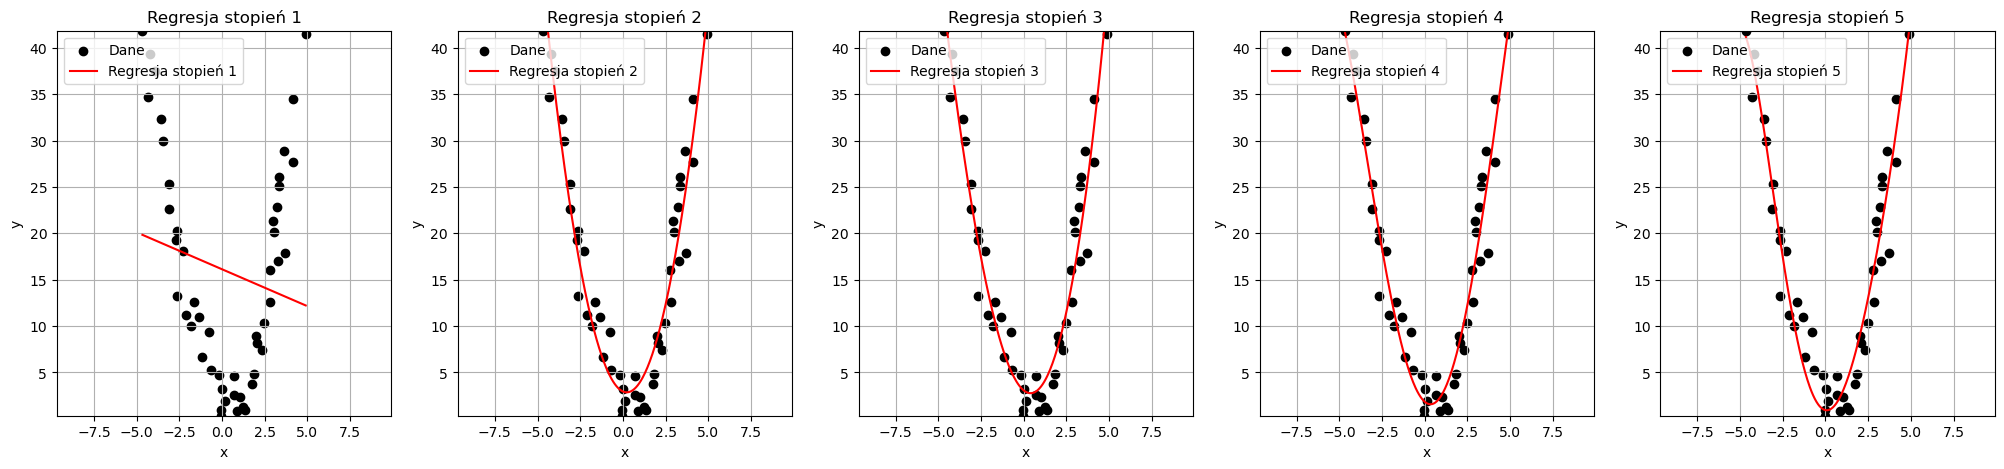

In [18]:
degrees = [1, 2, 3, 4, 5]
alphas = [0.1, 0.001, 0.001, 0.00001, 0.000001]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

x_plot = np.linspace(x_ic.min(), x_ic.max(), 200)

for ax, n, alpha in zip(axes, degrees, alphas):
    b0_list, betas_list, errors_list, _, _ = learn_and_fit(x_ic, y_ic, alpha=alpha, n=n)
    b0 = b0_list[-1]
    betas = betas_list[-1]

    X_poly = np.vstack([x_plot ** i for i in range(1, len(betas) + 1)])
    y_fit = b0 + np.dot(betas, X_poly)

    ax.scatter(x_ic, y_ic, color='black', label='Dane')
    ax.plot(x_plot, y_fit, color='red', label=f'Regresja stopień {n}')
    ax.set_title(f'Regresja stopień {n}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(x_ic.min() - 5, x_ic.max() + 5)
    ax.set_ylim(y_ic.min(), y_ic.max())
    ax.legend(loc=2)
    ax.grid(True)



Po wykresie widać, że wraz ze wzrostem stopnia wielomianu funkcja regresji coraz lepiej dopasowuje się do danych. Dla wielomianu pierwszego stopnia funkcja jest liniowa i nie oddaje dobrze zależności między temperaturą a sprzedażą lodów. Dla wielomianu drugiego, trzeciego, czwartego i piątego stopnia funkcja staje się bardziej złożona i lepiej odwzorowuje zmiany w danych. Wykorzystanie metryk z następnego podpounktu pozwoliłoby na dokładniejszą ocenę jakości dopasowania. Wydaje się , że już wielomian drugiego stopnia dobrze oddaje charakterystykę danych, ale dalsze zwiększanie stopnia może prowadzić do  niepotrzebnych obciążeń obliczeniowych i ryzyka przeuczenia modelu.

### Zadanie 6

Zaproponuj metrykę oceny skuteczności działania algorytmu. Można wzorować się na metodach dostępnych pod odnośnikiem: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics

In [19]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [20]:
for i in range(1, 6):
    b0_list, betas_list, errors_list, _, _ = learn_and_fit(x_ic, y_ic, alpha=0.000001, n=i)
    x_ic_poly = transform_to_polynomial_feature(x_ic, i)
    b0 = b0_list[-1]
    betas = betas_list[-1]
    y_fit = b0 + np.dot(betas, x_ic_poly)
    print(f'Dla stopnia {i} RMSE:', root_mean_squared_error(y_ic, y_fit), ', MAE:', mean_absolute_error(y_ic, y_fit))



Dla stopnia 1 RMSE: 13.318688204037342 , MAE: 10.338660732018319
Dla stopnia 2 RMSE: 3.2737937529296084 , MAE: 2.746524005428338
Dla stopnia 3 RMSE: 3.2958657962913653 , MAE: 2.7922351625872603
Dla stopnia 4 RMSE: 2.9741434184366677 , MAE: 2.4849198799530763
Dla stopnia 5 RMSE: 3.0395034150352056 , MAE: 2.506739993199097


Najmniejszy root mean squared error oraz mean absolute error występuje dla wielomianu 4 stopnia.